# Qdrant & Image Data

## Setup 

In [195]:
import os
# SET THE FALLBACK VARIABLE BEFORE TORCH IS IMPORTED
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1' #I need this to use the mac GPU (some operations are not supported on MPS)

In [196]:
# general
import random
import numpy as np
import matplotlib.pyplot as plt

# huggingface
from transformers import AutoModel
from datasets import load_dataset

# qdrant
from qdrant_client import QdrantClient
from qdrant_client import models

# torch
import torch
from torch import optim
from torch.utils.data import DataLoader

# pytorch metric learning
from pytorch_metric_learning import distances, losses, miners, reducers

# torchvision
import torchvision
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils

# PIL
from PIL import Image
import PIL.ImageOps    

## Data

In [ ]:
import pandas as pd

# Load the dataset
dataset = load_dataset("imagefolder", data_dir='./tilda-data/', split='train')

Resolving data files:   0%|          | 0/25600 [00:00<?, ?it/s]

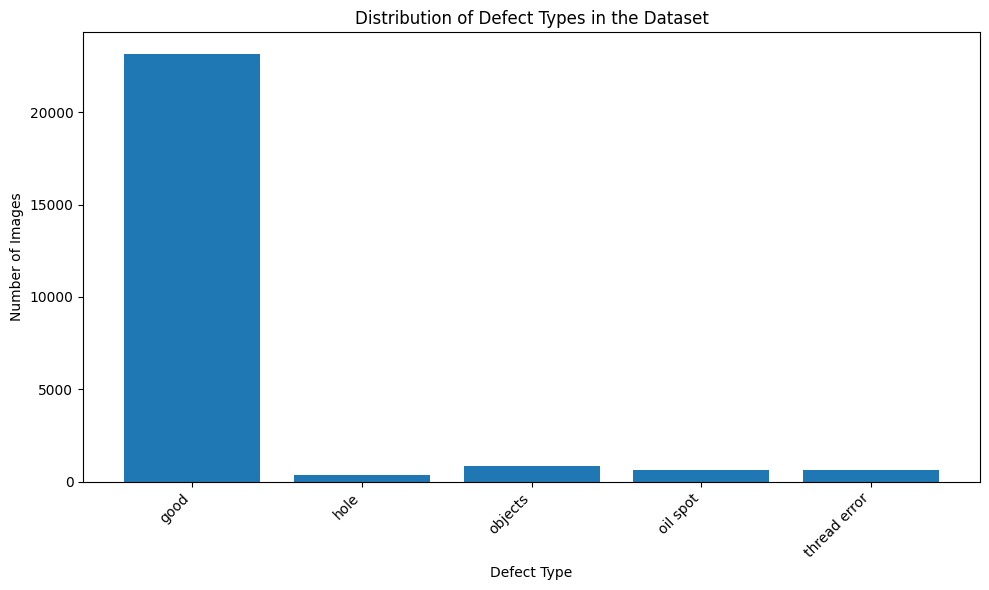

In [ ]:
import pandas as pd

# Load the dataset
dataset = load_dataset("imagefolder", data_dir='./tilda-data/', split='train')

In [ ]:
# Convert the 'label' column to a Pandas Series
labels_series = pd.Series(dataset['label'])

# Get the counts of each label
label_counts = labels_series.value_counts().sort_index()

# Get the label names from the dataset features
label_names = dataset.features['label'].names

# Create the bar plot
plt.figure(figsize=(10, 6))
plt.bar(label_names, label_counts)
plt.xlabel("Defect Type")
plt.ylabel("Number of Images")
plt.title("Distribution of Defect Types in the Dataset")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [85]:
#filtering out the images with no defects
dataset = dataset.filter(lambda x: x['label'] != 0)

Filter:   0%|          | 0/25600 [00:00<?, ? examples/s]

['good', 'hole', 'objects', 'oil spot', 'thread error']
1


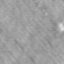

In [94]:
print(dataset.features['label'].names)
print(dataset[0]['label'])
dataset[0]['image']


In [97]:
# splitting the data
split_dataset = dataset.train_test_split(test_size=0.9, seed=1412)

# Access the new splits
train_set = split_dataset["train"]
val_set = split_dataset["test"]  # this is your validation set

print(f"Train size: {len(train_set)}")
print(f"Validation size: {len(val_set)}")

Train size: 243
Validation size: 2187


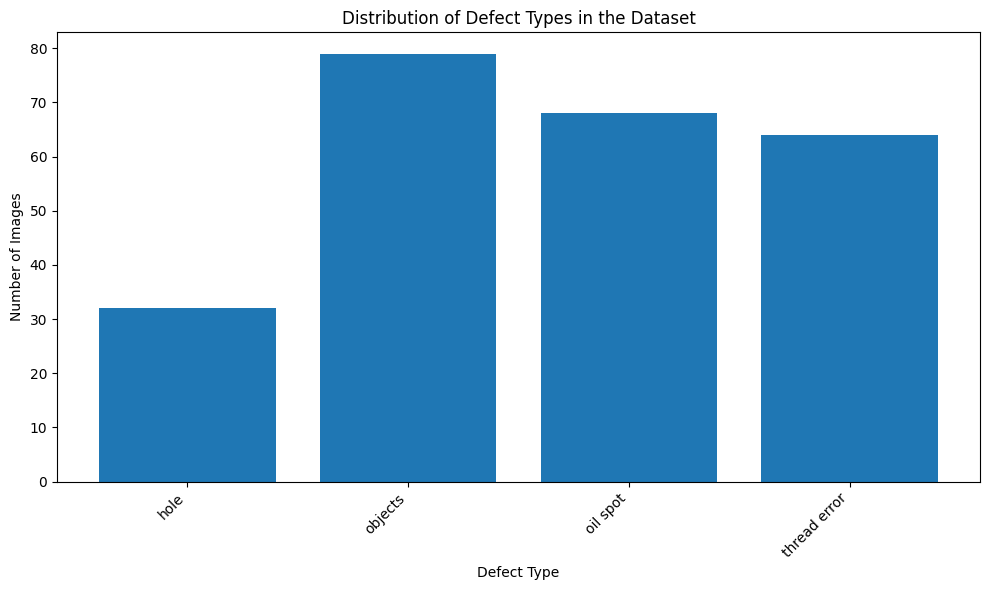

In [223]:
# Convert the 'label' column to a Pandas Series
labels_series = pd.Series(split_dataset['train']['label'])

# Get the counts of each label
label_counts = labels_series.value_counts().sort_index()

# Get the label names from the dataset features
label_names = dataset.features['label'].names
label_names.pop(0)

# Create the bar plot
plt.figure(figsize=(10, 6))
plt.bar(label_names, label_counts)
plt.xlabel("Defect Type")
plt.ylabel("Number of Images")
plt.title("Distribution of Defect Types in the Dataset")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [222]:
dataset.features['label'].names

['good', 'hole', 'objects', 'oil spot', 'thread error']

## Define the network

The feature extractor we're using is `ViTModel`. To learn more about `ViTImageProcessor`
and `ViTModel`, check out the [docs here](https://huggingface.co/docs/transformers/tasks/image_classification).

In [199]:
from src.cnn import ViTNetwork

device = torch.device("mps") #torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_model = AutoModel.from_pretrained("facebook/dinov2-base").to(device)

# Create the model
custom_model = ViTNetwork(base_model,1).to(device)

Unfreezing layer: layernorm.bias


In [201]:
custom_model.load_state_dict(torch.load('./models/finetuned-arcface-ViT.pth'))

<All keys matched successfully>

## Embeddings

Let's create a function with the process we just walked through above and map it to our dataset to get an
embedding vector for each image.

In [202]:
from transformers import AutoImageProcessor
processor = AutoImageProcessor.from_pretrained("facebook/dinov2-base")

def get_embeddings(batch):
    inputs = processor(images=batch['image'], return_tensors="pt").to(device)
    with torch.no_grad():
        embeddings = custom_model(inputs['pixel_values']).cpu().numpy()
    batch['embeddings'] = embeddings
    return batch

In [203]:
split_dataset['train'] = split_dataset['train'].map(get_embeddings, batched=True, batch_size=1)
split_dataset['train']

Map:   0%|          | 0/243 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'label', 'embeddings'],
    num_rows: 243
})

Visualize the embeddings

In [204]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def plot_tsne(X, y, title):
    tsne = TSNE(n_components=2, random_state=42)
    X_embedded = tsne.fit_transform(X)
    
    plt.figure(figsize=(8, 6))
    for label in np.unique(y):
        idx = y == label
        plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1], label=f"Class {label}", alpha=0.7)
    plt.title(title)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend()
    plt.grid(True)
    plt.show()

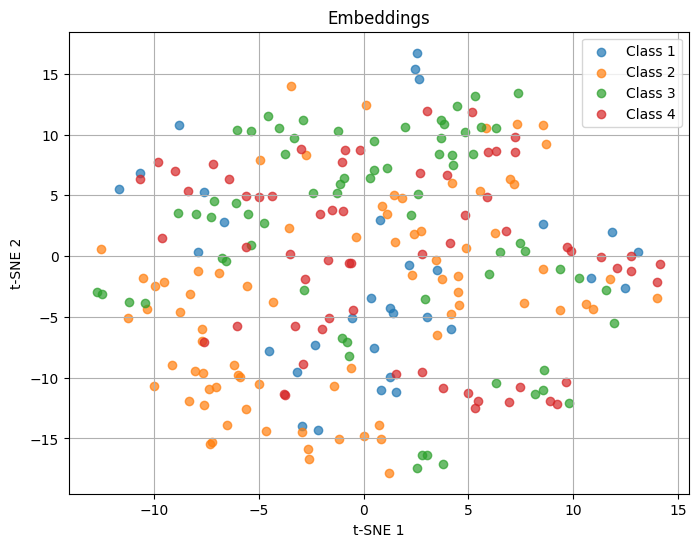

In [205]:
plot_tsne(np.array(split_dataset['train']['embeddings']),np.array(split_dataset['train']['label']),"Embeddings")

In [206]:
np.save("vectors", np.array(split_dataset['train']['embeddings']), allow_pickle=False)

## Fit embeddings into QDrant vector DB

In [207]:
from qdrant_client import QdrantClient
from qdrant_client import models

client = QdrantClient(location=":memory:")

my_collection = "image_collection"
client.recreate_collection(
    collection_name=my_collection,
    vectors_config=models.VectorParams(size=1536, distance=models.Distance.COSINE)
)

/var/folders/7g/9rtz76hn4j5_ws3_z5kszxk40000gn/T/ipykernel_64322/2215522899.py:7: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  client.recreate_collection(


True

Notice above that we now have an embedding for each of the images in our dataset, and that's exactly what we were hoping for.

We'll now save the vector of embeddings as a NumPy array so that we don't have to run it again later if
take a break or accidentally close down the tutorial. Then, what we want to do is to create a payload
with the metadata about each of our images. We can accomplish this by converting the rest of the
columns we didn't use into a JSON object for each sample.

In [208]:
payload = split_dataset['train'].select_columns([]).to_pandas().to_dict(orient="records")

payload[:3]

[]

To make sure each image has an explicit `id` inside of the Qdrant collection we created earlier, we'll create a new column with a range of
numbers equivalent to the rows in our dataset. In addition, we'll load the embeddings we just saved.

In [209]:
ids = list(range(split_dataset['train'].num_rows))
embeddings = np.load("vectors.npy").tolist()

We are now ready to upsert the combination of ids, vectors and payload to our collection, and we'll do so in batches of 1000.

In [210]:
batch_size = 1

for i in range(0, split_dataset['train'].num_rows, batch_size):

    low_idx = min(i+batch_size, split_dataset['train'].num_rows)

    batch_of_ids = ids[i: low_idx]
    batch_of_embs = embeddings[i: low_idx]
    if payload:
        batch_of_payloads = payload[i: low_idx]
    else:
        batch_of_payloads = [{} for _ in range(batch_size)]
    

    client.upsert(
        collection_name=my_collection,
        points=models.Batch(
            ids=batch_of_ids,
            vectors=batch_of_embs,
            payloads=batch_of_payloads
        )
    )

We can make sure our vectors were uploaded successfully by counting them with the `client.count()` method.

In [211]:
client.count(
    collection_name=my_collection,
    exact=True,
)

CountResult(count=243)

To visually inspect the collection we just created, we can scroll through our vectors with the `client.scroll()` method.

In [212]:
client.scroll(
    collection_name=my_collection,
    limit=5
)

([Record(id=0, payload={}, vector=None, shard_key=None, order_value=None),
  Record(id=1, payload={}, vector=None, shard_key=None, order_value=None),
  Record(id=2, payload={}, vector=None, shard_key=None, order_value=None),
  Record(id=3, payload={}, vector=None, shard_key=None, order_value=None),
  Record(id=4, payload={}, vector=None, shard_key=None, order_value=None)],
 5)

## 4. Semantic Search

Semantic search, in the context of vector databases and image retrieval, refers to a method of searching for information or images
based on their meaning or content rather than just using keywords. Imagine you're looking for a specific picture of a skin disease and you
don't know the file name or where it is stored. With semantic search, you can describe what you're looking for using words like
"red rashes with blisters," or you can upload an image that will get processed into an embedding vector, and the system will then analyze
the content of the images to find matches that closely match your description or input image.

Semantic search enables a more intuitive and efficient way of searching for images, making it easier to find what you're
looking for, even if you can't remember specific details or tags.

With Qdrant, we can get started searching through our collection with the `client.search()` method.

In [213]:
split_dataset['test'] = split_dataset['test'].map(get_embeddings, batched=True, batch_size=1)
split_dataset['test']

Map:   0%|          | 0/2187 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'label', 'embeddings'],
    num_rows: 2187
})

In [214]:
res = client.query_points(
    collection_name=my_collection,
    query=split_dataset['test'][0]['embeddings'],
    limit=3
).points
res

[ScoredPoint(id=122, version=0, score=0.8989297656591929, payload={}, vector=None, shard_key=None, order_value=None),
 ScoredPoint(id=27, version=0, score=0.8664121118913874, payload={}, vector=None, shard_key=None, order_value=None),
 ScoredPoint(id=79, version=0, score=0.8456430007645257, payload={}, vector=None, shard_key=None, order_value=None)]

Test on all test images

In [215]:
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score, classification_report

label_names = split_dataset['train'].features['label'].names
label_mapping = {name: idx for idx, name in enumerate(label_names)}

In [216]:
keys = list(label_mapping.keys())
keys.pop(0)
keys

['hole', 'objects', 'oil spot', 'thread error']

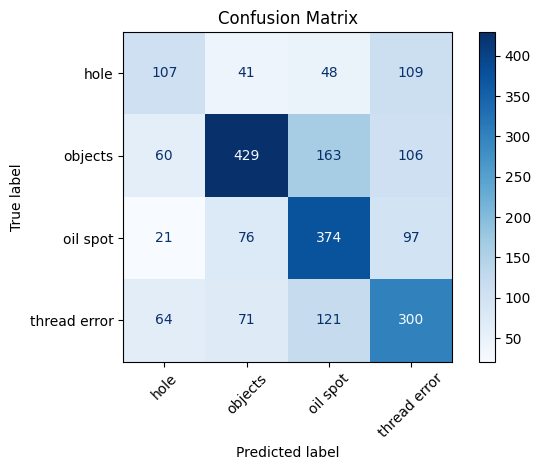

In [217]:
# Test all images in test dataset
y_true = []
y_pred = []
for img in split_dataset['test']:
    
    result = client.query_points(
        collection_name=my_collection,
        query=img['embeddings'],
        limit=1
    ).points

    # Append original class and predicted class
    y_true.append(label_names[img['label']])
    y_pred.append(label_names[split_dataset['train'][result[0].id]['label']])

    

# Create the confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=keys)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [218]:
report = classification_report(y_true, y_pred, target_names=keys)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

        hole       0.42      0.35      0.38       305
     objects       0.70      0.57      0.62       758
    oil spot       0.53      0.66      0.59       568
thread error       0.49      0.54      0.51       556

    accuracy                           0.55      2187
   macro avg       0.53      0.53      0.53      2187
weighted avg       0.56      0.55      0.55      2187

